# Hyperparameter Optimization

In [22]:
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score
from catboost import CatBoostClassifier
from skopt.space import Integer, Real

import sys 
from datetime import datetime
import shutil
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load / Reload Selection Utility Functions

In [68]:
from utils2 import optimization as hpo

----

## Read Config File

In [24]:
config_path = Path(r'experiments')

# choose between final and development config file
config_filename = "bin_opt_dev.yml" # development
#config_file_name = "bin_opt_final.yml" # final

config_dict = ymlconfig.load_config(config_path / config_filename)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict


{'experiment': {'summary': 'binary classification - hyperparameter optimization (development)',
  'classification_type': 'binary',
  'stage': 'hyperparameter_optimization',
  'tag': 'development',
  'verbosity': 1,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'model': {'name': 'catboost', 'code': 'CatBoost'},
 'param_space': {'iterations': {'min': 100, 'max': 500},
  'depth': {'min': 4, 'max': 10},
  'learning_rate': {'min': 0.01, 'max': 0.1},
  'l2_leaf_reg': {'min': 1, 'max': 9}},
 'optimization': {'scoring': 'roc_auc',
  'k_splits_outer': 3,
  'n_repeats_outer': 2,
  'k_splits_inner': 3,
  'n_iter': 5},
 'evaluation': {'confidence': 0.95},
 'final_training': {'k_splits_inner': 3, 'n_iter': 5}}

#### Set output directory

In [26]:
outputdir = config_path /  config.experiment.classification_type /  config.experiment.stage / config.model.code / config.experiment.tag 
outputdir.mkdir(parents=True, exist_ok=True)
print(outputdir)

experiments\binary\hyperparameter_optimization\CatBoost\development


#### Copy config file to output directory

In [27]:
source = config_path / config_filename
destination = outputdir / config_filename
shutil.copy(source, destination)

WindowsPath('experiments/binary/hyperparameter_optimization/CatBoost/development/bin_opt_dev.yml')

## Data Loading

In [28]:
D = DPN_data(config.data.dataset_path)
D.load(classification=config.experiment.classification_type)

dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
X = dfdpn[data_cols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

## Optuna Bayes Search Optimization

In [29]:
config.param_space

namespace(iterations=namespace(min=100, max=500),
          depth=namespace(min=4, max=10),
          learning_rate=namespace(min=0.01, max=0.1),
          l2_leaf_reg=namespace(min=1, max=9))

In [30]:
hpo.model_class[config.model.name]

catboost.core.CatBoostClassifier

In [31]:
config.optimization

namespace(scoring='roc_auc',
          k_splits_outer=3,
          n_repeats_outer=2,
          k_splits_inner=3,
          n_iter=5)

In [32]:
def param_space_fn(trial):
    return  {
        "iterations": trial.suggest_int(
            "iterations", 
            config.param_space.iterations.min, 
            config.param_space.iterations.max),
        "depth": trial.suggest_int(
            "depth", 
            config.param_space.depth.min, 
            config.param_space.depth.max),
        "learning_rate": trial.suggest_float(
            "learning_rate", 
            config.param_space.learning_rate.min, 
            config.param_space.learning_rate.max, 
            log=True),
        "l2_leaf_reg": trial.suggest_int(
            "l2_leaf_reg", 
            config.param_space.l2_leaf_reg.min, 
            config.param_space.l2_leaf_reg.max),
    }


In [33]:
opt_results = hpo.nested_cv_youden_optuna(
    X=X.values,
    y=y.values,
    model_class=hpo.model_class[config.model.name],   # class, not an instance
    param_space_fn=param_space_fn,
    n_splits_outer=config.optimization.k_splits_outer,
    n_repeats_outer=config.optimization.n_repeats_outer,
    n_splits_inner=config.optimization.k_splits_inner,
    n_iter=config.optimization.n_iter,   # Optuna trials per outer fold
    random_state=config.experiment.random_seed,
)

In [34]:
opt_results

{'roc_auc_mean': 0.9692212825933756,
 'roc_auc_std': 0.018776054590824542,
 'youden_mean': 0.7956483439041578,
 'youden_std': 0.08021401914153416,
 'sensitivity_mean': 0.9039816772374912,
 'specificity_mean': 0.8916666666666666,
 'threshold_mean': 0.6488591221384802,
 'threshold_std': 0.14354802298703395,
 'folds': [{'fold': 0,
   'roc_auc': 0.9840909090909091,
   'youden': 0.9090909090909092,
   'sensitivity': 0.9090909090909091,
   'specificity': 1.0,
   'threshold': 0.7137815889585889,
   'best_params': {'iterations': 433,
    'depth': 5,
    'learning_rate': 0.015199348301309814,
    'l2_leaf_reg': 2}},
  {'fold': 1,
   'roc_auc': 0.9755813953488373,
   'youden': 0.6499999999999999,
   'sensitivity': 1.0,
   'specificity': 0.65,
   'threshold': 0.3794176963815851,
   'best_params': {'iterations': 231,
    'depth': 10,
    'learning_rate': 0.04635431984752397,
    'l2_leaf_reg': 5}},
  {'fold': 2,
   'roc_auc': 0.9348837209302325,
   'youden': 0.8069767441860465,
   'sensitivity': 0

### Calculate Confidence Interval 

In [35]:
opt_ci  = hpo.mean_confidence_interval(opt_results, config)
opt_ci

youden 95.0% CI: {'mean': 0.7956483439041578, 'std': 0.08787005542393887, 'ci_lower': 0.7253389480563618, 'ci_upper': 0.8659577397519539, 'n_folds': 6}
roc_auc 95.0% CI: {'mean': 0.9692212825933756, 'std': 0.020568137280686065, 'ci_lower': 0.9527636475214215, 'ci_upper': 0.9856789176653297, 'n_folds': 6}


{'youden': {'mean': 0.7956483439041578,
  'std': 0.08787005542393887,
  'ci_lower': 0.7253389480563618,
  'ci_upper': 0.8659577397519539,
  'n_folds': 6},
 'roc_auc': {'mean': 0.9692212825933756,
  'std': 0.020568137280686065,
  'ci_lower': 0.9527636475214215,
  'ci_upper': 0.9856789176653297,
  'n_folds': 6}}

### Optimization Summary

In [36]:
opt_results_summary = {
    'youden': f'{opt_results["youden_mean"]:.3f} +/ {opt_results["youden_std"]:.3f}',
    'youden ci': f'{opt_ci["youden"]["ci_lower"]:.3f} - {opt_ci["youden"]["ci_upper"]:.3f}', 
    'roc_auc': f'{opt_results["roc_auc_mean"]:.3f} +/ {opt_results["roc_auc_std"]:.3f}',
    'roc_auc ci': f'{opt_ci["roc_auc"]["ci_lower"]:.3f} - {opt_ci["roc_auc"]["ci_upper"]:.3f}', 
    'threshold': f'{opt_results["threshold_mean"]:.3f} +/ {opt_results["threshold_std"]:.3f}',
    'specificity mean': f'{opt_results["specificity_mean"]:.3f}',
    'sensitivity mean': f'{opt_results["sensitivity_mean"]:.3f}',
}

opt_results_df = pd.DataFrame(opt_results_summary, index=['value']).T
opt_results_df

,value
youden,0.796 +/ 0.080
youden ci,0.725 - 0.866
roc_auc,0.969 +/ 0.019
roc_auc ci,0.953 - 0.986
threshold,0.649 +/ 0.144
specificity mean,0.892
sensitivity mean,0.904


### Save and verify artifacts and metrics 

##### Metrics

In [37]:
opt_results

{'roc_auc_mean': 0.9692212825933756,
 'roc_auc_std': 0.018776054590824542,
 'youden_mean': 0.7956483439041578,
 'youden_std': 0.08021401914153416,
 'sensitivity_mean': 0.9039816772374912,
 'specificity_mean': 0.8916666666666666,
 'threshold_mean': 0.6488591221384802,
 'threshold_std': 0.14354802298703395,
 'folds': [{'fold': 0,
   'roc_auc': 0.9840909090909091,
   'youden': 0.9090909090909092,
   'sensitivity': 0.9090909090909091,
   'specificity': 1.0,
   'threshold': 0.7137815889585889,
   'best_params': {'iterations': 433,
    'depth': 5,
    'learning_rate': 0.015199348301309814,
    'l2_leaf_reg': 2}},
  {'fold': 1,
   'roc_auc': 0.9755813953488373,
   'youden': 0.6499999999999999,
   'sensitivity': 1.0,
   'specificity': 0.65,
   'threshold': 0.3794176963815851,
   'best_params': {'iterations': 231,
    'depth': 10,
    'learning_rate': 0.04635431984752397,
    'l2_leaf_reg': 5}},
  {'fold': 2,
   'roc_auc': 0.9348837209302325,
   'youden': 0.8069767441860465,
   'sensitivity': 0

In [44]:
import json
with open(outputdir / "optimization_results.json", "w") as f:
    json.dump(opt_results, f, indent=4)

opt_results_df.to_csv(outputdir / "optimization_results_summary.csv", index=False)

In [45]:
with open(outputdir / "optimization_results.json", "r") as f:
    loaded_optimization_results = json.load(f)
loaded_optimization_results

{'roc_auc_mean': 0.9692212825933756,
 'roc_auc_std': 0.018776054590824542,
 'youden_mean': 0.7956483439041578,
 'youden_std': 0.08021401914153416,
 'sensitivity_mean': 0.9039816772374912,
 'specificity_mean': 0.8916666666666666,
 'threshold_mean': 0.6488591221384802,
 'threshold_std': 0.14354802298703395,
 'folds': [{'fold': 0,
   'roc_auc': 0.9840909090909091,
   'youden': 0.9090909090909092,
   'sensitivity': 0.9090909090909091,
   'specificity': 1.0,
   'threshold': 0.7137815889585889,
   'best_params': {'iterations': 433,
    'depth': 5,
    'learning_rate': 0.015199348301309814,
    'l2_leaf_reg': 2}},
  {'fold': 1,
   'roc_auc': 0.9755813953488373,
   'youden': 0.6499999999999999,
   'sensitivity': 1.0,
   'specificity': 0.65,
   'threshold': 0.3794176963815851,
   'best_params': {'iterations': 231,
    'depth': 10,
    'learning_rate': 0.04635431984752397,
    'l2_leaf_reg': 5}},
  {'fold': 2,
   'roc_auc': 0.9348837209302325,
   'youden': 0.8069767441860465,
   'sensitivity': 0

In [46]:
pd.read_csv(outputdir / "optimization_results_summary.csv", index_col=0)

""
value
0.796 +/ 0.080
0.725 - 0.866
0.969 +/ 0.019
0.953 - 0.986
0.649 +/ 0.144
0.892
0.904


 -----

## Train final model on ALL data

Read threshold mean from file

In [47]:
hpo_results_path = config_path /  config.experiment.classification_type / config.experiment.stage / config.model.code / config.experiment.tag / 'optimization_results.json'
with open(outputdir / "optimization_results.json", "r") as f:
    optimization_results = json.load(f)
threshold_mean = optimization_results['threshold_mean']
threshold_mean

0.6488591221384802

In [48]:
catboost_model = CatBoostClassifier(
    verbose=0,
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=config.experiment.random_seed, 
    thread_count=-1
)

In [49]:
param_space = {
    'iterations': Integer(
        config.param_space.iterations.min, 
        config.param_space.iterations.max),
    'depth': Integer(
        config.param_space.depth.min, 
        config.param_space.depth.max),
    'learning_rate': Real(
        config.param_space.learning_rate.min, 
        config.param_space.learning_rate.max, 
        prior='log-uniform'),  # log-uniform better for LR
    'l2_leaf_reg': Real(
        config.param_space.l2_leaf_reg.min, 
        config.param_space.l2_leaf_reg.max, 
        prior='uniform'),
}

In [50]:
config.final_training

namespace(k_splits_inner=3, n_iter=5)

In [51]:
final_model, best_params = hpo.train_final_model(
    X=X.values, 
    y=y.values, 
    model=catboost_model,
    param_space=param_space,
    n_splits_inner=config.final_training.k_splits_inner,
    n_iter=config.final_training.n_iter, 
    random_state=config.experiment.random_seed, 
    n_jobs=1
)

In [52]:
print(best_params) 

OrderedDict({'depth': 6, 'iterations': 391, 'l2_leaf_reg': 8.462943990782671, 'learning_rate': 0.02069186296126172})


 -----

### Final Model Sample Prediction

In [53]:
# 0.63 is the mean threshold, we just hardcode here
hpo.test_model(final_model, threshold_mean, X, y)


[[ 60   0]
 [  0 130]]
youden:  1.0
roc_auc:  1.0


(1.0, 1.0)

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
hpo.test_model(final_model, threshold_mean, X_test, y_test)


[[11  0]
 [ 0 37]]
youden:  1.0
roc_auc:  1.0


(1.0, 1.0)

 -----

## Explainability Model Selection

Study on what model to use for counterfactuals

### Regularized Model Evaluation

In [57]:
regularized_model = CatBoostClassifier(
    depth=4,
    l2_leaf_reg=10,
    iterations=300,
    learning_rate=0.05,
    verbose=0
)
regularized_model.fit(X,y)
hpo.test_model(regularized_model, threshold_mean, X, y)


[[ 60   0]
 [  0 130]]
youden:  1.0
roc_auc:  1.0


(1.0, 1.0)

### Unoptimized, Train-Test-Split Model Evaluation

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

unoptimized_model = CatBoostClassifier(verbose=0)
unoptimized_model.fit(X_train.values, y_train.values)
hpo.test_model(unoptimized_model, threshold_mean, X_test, y_test)


[[10  1]
 [ 3 34]]
youden:  0.828009828009828
roc_auc:  0.9803439803439803


(0.828009828009828, 0.9803439803439803)

### Optimized, Train-Test-Split Model Evaluation

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

optsplit_model, optsplit_best_params = hpo.train_final_model(
    X=X_train.values, 
    y=y_train.values, 
    model=catboost_model,
    param_space=param_space,
    n_splits_inner=config.final_training.k_splits_inner,
    n_iter=config.final_training.n_iter, 
    random_state=config.experiment.random_seed, 
    n_jobs=1
)

In [60]:
optsplit_model = CatBoostClassifier(**optsplit_best_params, verbose=0)
optsplit_model.fit(X_train.values, y_train.values)
hpo.test_model(unoptimized_model, threshold_mean, X_test, y_test)


[[10  1]
 [ 3 34]]
youden:  0.828009828009828
roc_auc:  0.9803439803439803


(0.828009828009828, 0.9803439803439803)

*We will use this methodology for generating counterfactuals, but we will do it for 4 folds*

### Distilled Model

#### Ridge

In [61]:
from sklearn.linear_model import Ridge

# probabilities from CatBoost
y_soft = final_model.predict_proba(X)[:,1]

distilled_model_ridge = Ridge()
distilled_model_ridge.fit(X, y_soft)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [62]:
hpo.test_model(distilled_model_ridge, threshold_mean, X, y, True)


[[ 57   3]
 [ 16 114]]
youden:  0.8269230769230769
roc_auc:  0.977948717948718


(0.8269230769230769, 0.977948717948718)

In [63]:
from sklearn.metrics import classification_report

y_pred_proba = distilled_model_ridge.predict(X)
y_pred = (y_pred_proba >= 0.63).astype(int)
print(classification_report(y, y_pred))

tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

              precision    recall  f1-score   support

           0       0.81      0.95      0.88        60
           1       0.97      0.90      0.94       130

    accuracy                           0.92       190
   macro avg       0.89      0.93      0.91       190
weighted avg       0.92      0.92      0.92       190

TN: 57
FP: 3
FN: 13
TP: 117


#### Logistic Regression

In [64]:
from sklearn.linear_model import LogisticRegression

# probabilities from CatBoost
y_soft = final_model.predict_proba(X)[:,1]

distilled_model_logreg = LogisticRegression(max_iter=2000)
distilled_model_logreg.fit(X, y_soft > 0.5)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [65]:
hpo.test_model(distilled_model_logreg, 0.5, X, y, False)


[[ 55   5]
 [  5 125]]
youden:  0.8782051282051282
roc_auc:  0.9874358974358974


(0.8782051282051282, 0.9874358974358974)

### Surrogate Model

In [67]:
from sklearn.linear_model import LogisticRegression

surrogate_model = LogisticRegression(
    penalty="l2",
    C=0.1,
    class_weight="balanced",
    max_iter=1000
)

surrogate_model.fit(X, y)
surrogate_model_youden, final_model_roc_auc = hpo.test_model(surrogate_model, 0.5, X, y, False)


[[ 57   3]
 [  7 123]]
youden:  0.8961538461538461
roc_auc:  0.9761538461538461


### Mutual Info Classification

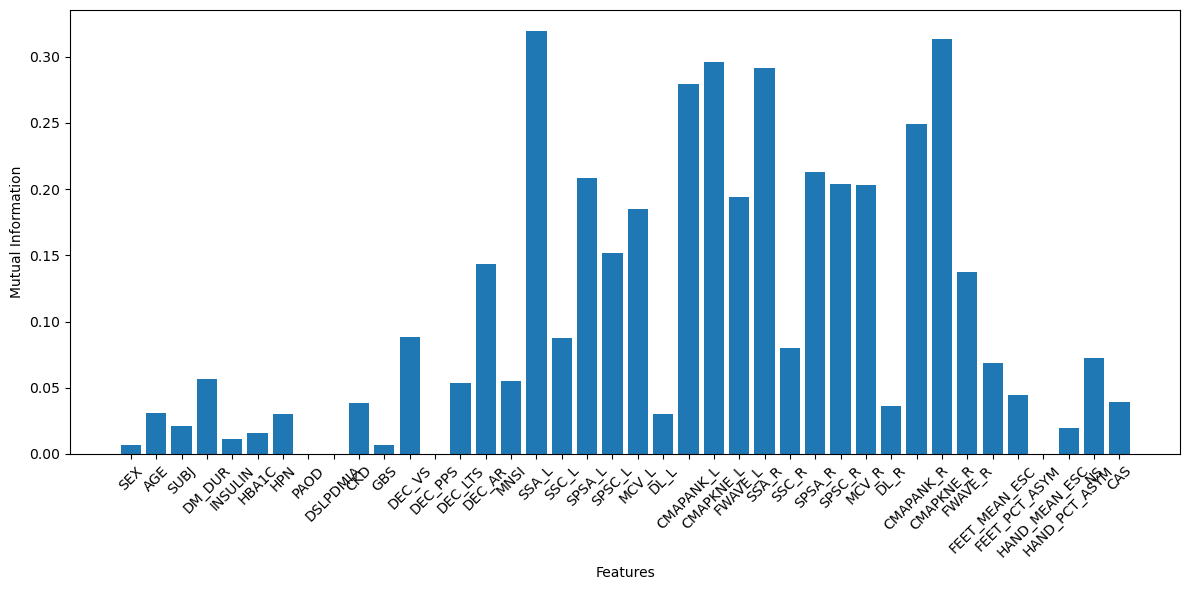

In [69]:
hpo.plot_mutual_info(X, y)